# Deep Learning for Time Series

Martin BOUCHER, Théo CHICHERY, Jérémie FORMEY DE SAINT LOUVENT

## LSST Multivariate Time Series Classification

### Context and Objectives

The goal of this project is to classidy time series
from the Large Synoptic Survey Telescope (LSST) dataset.

Each sample represents a light curve, the variation in brightness of an
astronomical object over time, and it's recorded across 6 photometric band/channel over 36 time steps. The classification goal is to identify the
nature of these samples from these multivariate temporal signals.

The notebook is structured as follows:
1. Exploratory Data Analysis (EDA): to understand the dataset structure and class distribution
2. Preprocessing: normalization and formatting for deep learning
3. Baseline model: a ResNet architecture for multivariate time series
   - 3.1 Architecture
   - 3.2 Supplementary Architecture — FCN
   - 3.3 Training Configuration
4. Evaluation — Baseline ResNet
5. Adapting a Foundation Model (Chronos)
   - 5.1 Motivation
   - 5.2 Handling class imbalance: Focal Loss
   - 5.3 Architecture: Chronos-LoRA
   - 5.4 Training Configuration
   - 5.5 Training and Evaluation
6. Analysis of the Results

In [1]:
import numpy as np
import matplotlib.pyplot as plt
!pip install tslearn
from tslearn.datasets import UCR_UEA_datasets

## 1. Exploratory Data Analysis

Before building any model, it was necessary to analyze the structure and properties of the dataset. This included verifying its integrity, checking for missing or invalid values, examining the class distribution, and visually inspecting the light curves to better understand the signal patterns.

The dataset follows the shape convention `(N, T, C)`:
- `N` — number of samples
- `T = 36` — number of time steps
- `C = 6` — number of photometric bands (channels)

In [2]:
# Load dataset
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

In [3]:
# 1. Structural integrity check
print(f"X_train shape: {X_train.shape} -> (Samples, Time_steps, Channels)")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (2459, 36, 6) -> (Samples, Time_steps, Channels)
X_test shape: (2466, 36, 6)
y_train shape: (2459,)


In [4]:
# 2. NaN or Infinite values check
print(f"NaN values in X_train: {np.isnan(X_train).sum()}")
print(f"Inf values in X_train: {np.isinf(X_train).sum()}")

NaN values in X_train: 0
Inf values in X_train: 0


In [5]:
# 3. Class distribution check
classes, counts = np.unique(y_train, return_counts=True)
print(f"Number of distinct classes: {len(classes)}")
for cls, count in zip(classes, counts):
    print(f"Class {cls}: {count} samples ({count/len(y_train)*100:.2f}%)")

Number of distinct classes: 14
Class 15: 123 samples (5.00%)
Class 16: 270 samples (10.98%)
Class 42: 381 samples (15.49%)
Class 52: 62 samples (2.52%)
Class 53: 7 samples (0.28%)
Class 6: 34 samples (1.38%)
Class 62: 153 samples (6.22%)
Class 64: 23 samples (0.94%)
Class 65: 313 samples (12.73%)
Class 67: 68 samples (2.77%)
Class 88: 120 samples (4.88%)
Class 90: 777 samples (31.60%)
Class 92: 77 samples (3.13%)
Class 95: 51 samples (2.07%)


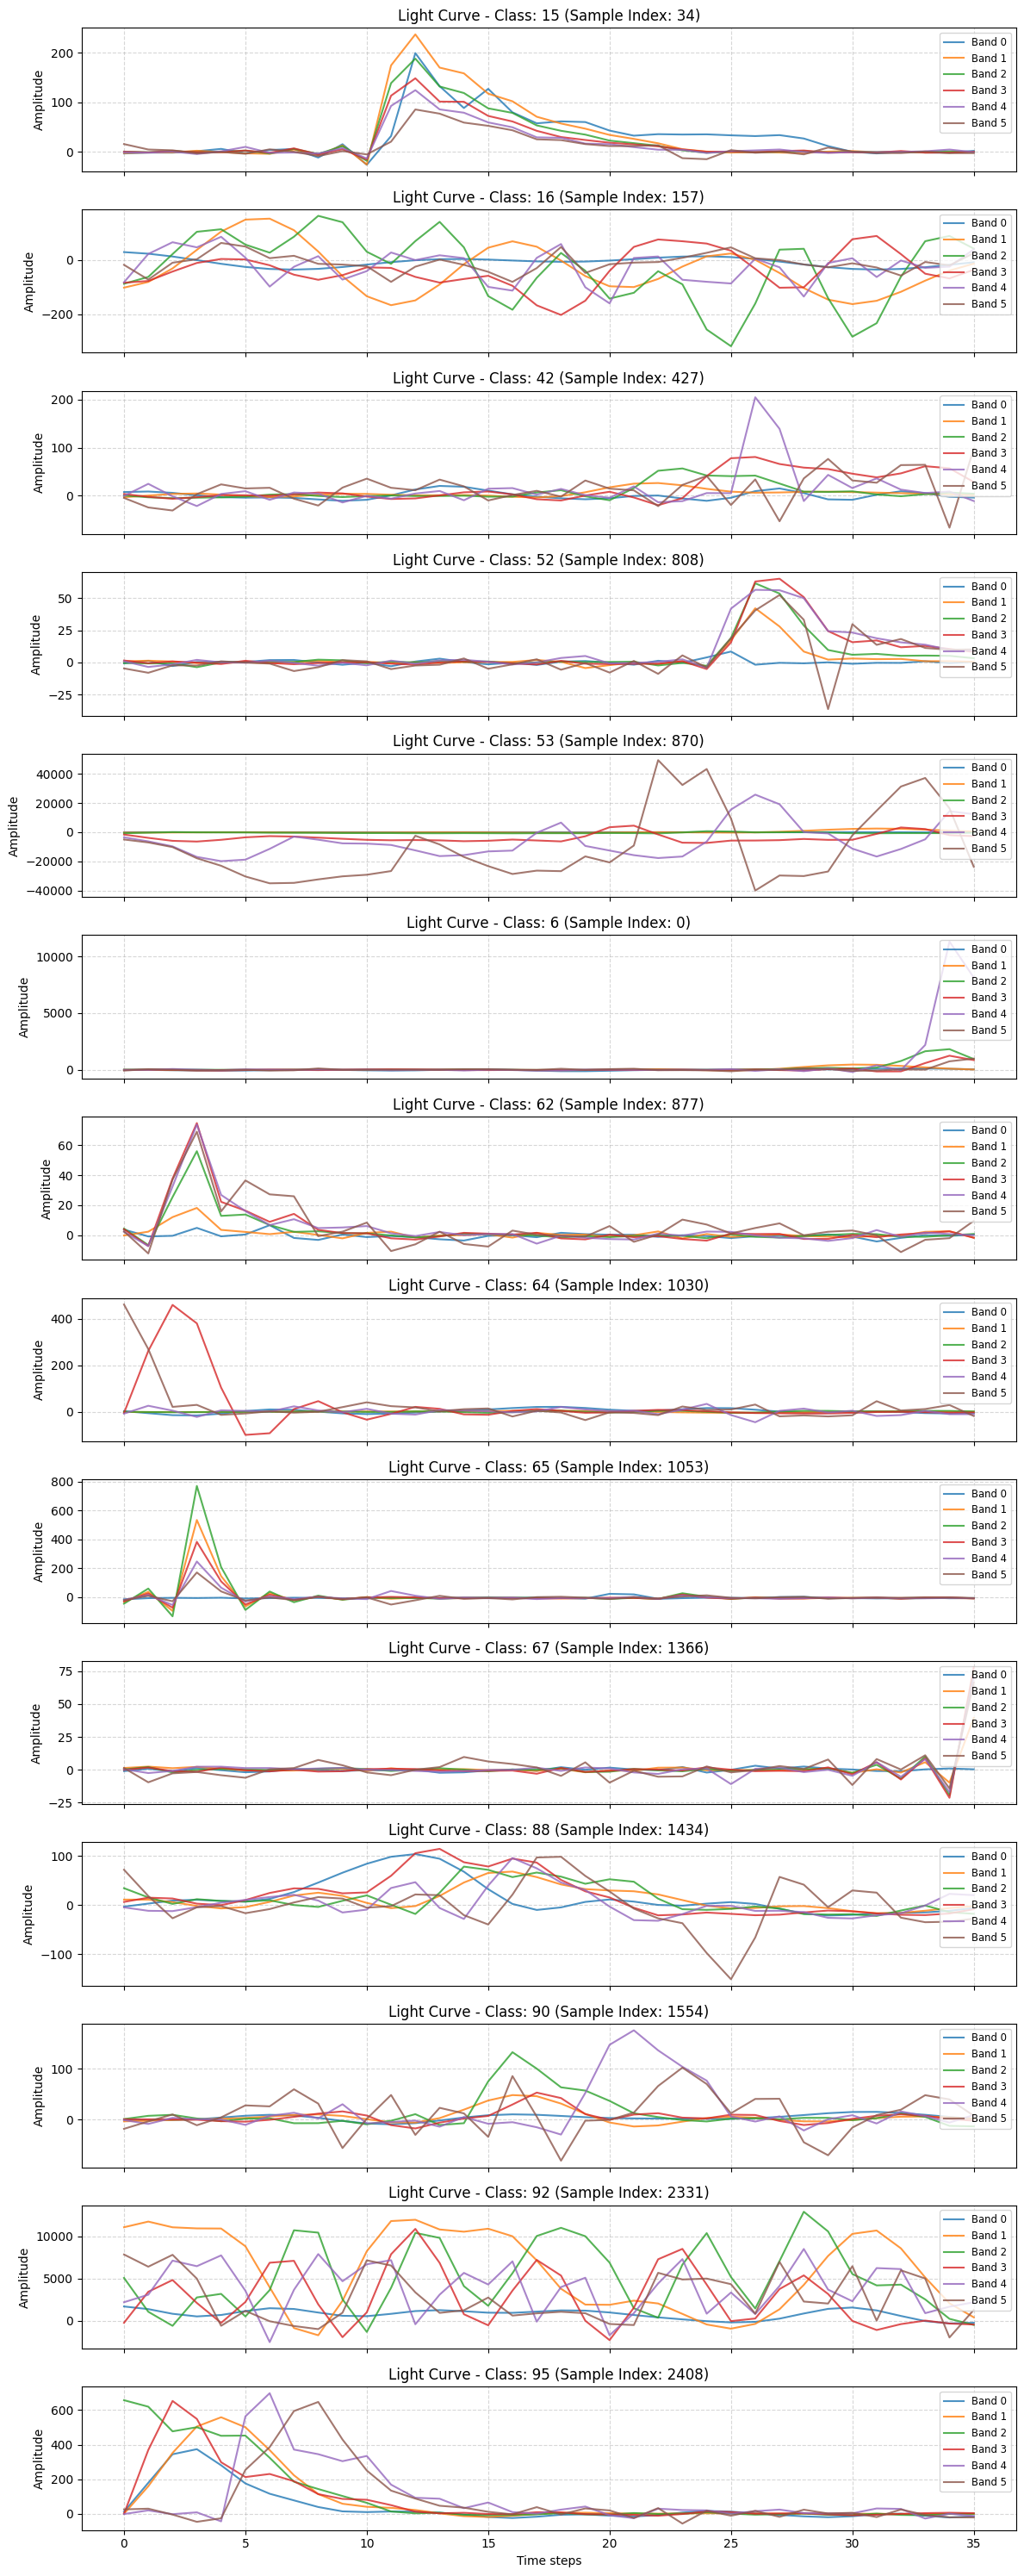

In [49]:
# 4. Visualization of distinct astronomical classes
classes_to_plot = classes
fig, axes = plt.subplots(len(classes_to_plot), 1, figsize=(12, 30), sharex=True)

for i, cls in enumerate(classes_to_plot):
    # Extract the first sample of the current class
    idx = np.where(y_train == cls)[0][0]
    sample = X_train[idx]

    # Plot all 6 photometric bands (channels) for this sample
    for channel in range(sample.shape[1]):
        axes[i].plot(sample[:, channel], label=f'Band {channel}', alpha=0.8)

    axes[i].set_title(f'Light Curve - Class: {cls} (Sample Index: {idx})')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend(loc='upper right', fontsize='small')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Time steps')
plt.tight_layout()

## 2. Preprocessing and Data Preparation

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

# Détection du hardware pour accélérer les calculs si un GPU est disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda



- **Label encoding:** String labels are mapped to integer indices as
required by PyTorch's `CrossEntropyLoss`.

- **Train / Validation split:** 20% hold-out with stratified sampling
to preserve class distribution across splits.

- **Normalization:** Per-channel standardization using training set
statistics only, applied consistently to validation and test sets to
prevent data leakage.

- **Tensor transposition:** Data is transposed from `(N, T, C)` to
`(N, C, T)` once here, as required by PyTorch's `Conv1d`.

- **DataLoaders:** `batch_size=64`, training set shuffled each epoch.

In [8]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import torch
import numpy as np

# 1. Label mapping
unique_classes = np.unique(y_train)
label_to_idx = {label: idx for idx, label in enumerate(unique_classes)}

y_train_idx = np.array([label_to_idx[lbl] for lbl in y_train])
y_test_idx = np.array([label_to_idx[lbl] for lbl in y_test])

# 2. Train and Validation split
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train_idx, test_size=0.2, random_state=42, stratify=y_train_idx
)

# Assuming X_train_sub, X_val, X_test have shape (N, Length, Channels) before transposition
means = X_train_sub.mean(axis=(0, 1), keepdims=True)
stds = X_train_sub.std(axis=(0, 1), keepdims=True)
stds[stds == 0] = 1e-8 # Prevent division by zero

X_train_sub = (X_train_sub - means) / stds
X_val = (X_val - means) / stds
X_test = (X_test - means) / stds


# 3. Tensor conversion and spatial transposition (N, Length, Channels) -> (N, Channels, Length)
X_train_tensor = torch.tensor(X_train_sub, dtype=torch.float32).transpose(1, 2)
y_train_tensor = torch.tensor(y_train_sub, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32).transpose(1, 2)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).transpose(1, 2)
y_test_tensor = torch.tensor(y_test_idx, dtype=torch.long)

# 4. DataLoaders instantiation
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

## 3. Baseline Model — ResNet for Time Series

### 3.1 Architecture

We implement the **ResNet** architecture proposed by Wang et al. (2017),
which remains one of the strongest baselines for time series classification
across UCR/UEA benchmarks.

The network consists of three residual blocks with convolutional layers of
decreasing kernel sizes (`8 → 5 → 3`), enabling the model to capture
temporal patterns at multiple scales within each photometric band. Skip
connections make the architecture robust to deeper stacking and are
particularly well-suited to time series, where relevant patterns can span
very different time horizons.

Feature maps grow from `64` (Block 1) to `128` (Blocks 2–3). A Global
Average Pooling layer collapses the temporal dimension before classification,
making the model invariant to sequence length — a useful property when
dealing with irregularly sampled astronomical surveys.

In [9]:
import torch
import torch.nn as nn
import copy

class Classifier_RESNET(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Classifier_RESNET, self).__init__()

        n_feature_maps = 64

        # BLOCK 1
        self.b1_conv1 = nn.Conv1d(in_channels, n_feature_maps, kernel_size=8, padding='same')
        self.b1_bn1 = nn.BatchNorm1d(n_feature_maps)

        self.b1_conv2 = nn.Conv1d(n_feature_maps, n_feature_maps, kernel_size=5, padding='same')
        self.b1_bn2 = nn.BatchNorm1d(n_feature_maps)

        self.b1_conv3 = nn.Conv1d(n_feature_maps, n_feature_maps, kernel_size=3, padding='same')
        self.b1_bn3 = nn.BatchNorm1d(n_feature_maps)

        self.b1_shortcut_conv = nn.Conv1d(in_channels, n_feature_maps, kernel_size=1, padding='same')
        self.b1_shortcut_bn = nn.BatchNorm1d(n_feature_maps)

        self.relu = nn.ReLU()

        # BLOCK 2
        self.b2_conv1 = nn.Conv1d(n_feature_maps, n_feature_maps * 2, kernel_size=8, padding='same')
        self.b2_bn1 = nn.BatchNorm1d(n_feature_maps * 2)

        self.b2_conv2 = nn.Conv1d(n_feature_maps * 2, n_feature_maps * 2, kernel_size=5, padding='same')
        self.b2_bn2 = nn.BatchNorm1d(n_feature_maps * 2)

        self.b2_conv3 = nn.Conv1d(n_feature_maps * 2, n_feature_maps * 2, kernel_size=3, padding='same')
        self.b2_bn3 = nn.BatchNorm1d(n_feature_maps * 2)

        self.b2_shortcut_conv = nn.Conv1d(n_feature_maps, n_feature_maps * 2, kernel_size=1, padding='same')
        self.b2_shortcut_bn = nn.BatchNorm1d(n_feature_maps * 2)

        # BLOCK 3
        self.b3_conv1 = nn.Conv1d(n_feature_maps * 2, n_feature_maps * 2, kernel_size=8, padding='same')
        self.b3_bn1 = nn.BatchNorm1d(n_feature_maps * 2)

        self.b3_conv2 = nn.Conv1d(n_feature_maps * 2, n_feature_maps * 2, kernel_size=5, padding='same')
        self.b3_bn2 = nn.BatchNorm1d(n_feature_maps * 2)

        self.b3_conv3 = nn.Conv1d(n_feature_maps * 2, n_feature_maps * 2, kernel_size=3, padding='same')
        self.b3_bn3 = nn.BatchNorm1d(n_feature_maps * 2)

        self.b3_shortcut_bn = nn.BatchNorm1d(n_feature_maps * 2)

        # FINAL
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(n_feature_maps * 2, num_classes)

        # Override initialization and BatchNorm defaults to match Keras
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                m.momentum = 0.1 # PyTorch's 0.1 matches Keras's 0.99 decay
                m.eps = 1e-3

    def forward(self, x):
        # BLOCK 1
        conv_x = self.relu(self.b1_bn1(self.b1_conv1(x)))
        conv_y = self.relu(self.b1_bn2(self.b1_conv2(conv_x)))
        conv_z = self.b1_bn3(self.b1_conv3(conv_y))

        shortcut_y = self.b1_shortcut_bn(self.b1_shortcut_conv(x))
        out_block_1 = self.relu(shortcut_y + conv_z)

        # BLOCK 2
        conv_x = self.relu(self.b2_bn1(self.b2_conv1(out_block_1)))
        conv_y = self.relu(self.b2_bn2(self.b2_conv2(conv_x)))
        conv_z = self.b2_bn3(self.b2_conv3(conv_y))

        shortcut_y = self.b2_shortcut_bn(self.b2_shortcut_conv(out_block_1))
        out_block_2 = self.relu(shortcut_y + conv_z)

        # BLOCK 3
        conv_x = self.relu(self.b3_bn1(self.b3_conv1(out_block_2)))
        conv_y = self.relu(self.b3_bn2(self.b3_conv2(conv_x)))
        conv_z = self.b3_bn3(self.b3_conv3(conv_y))

        shortcut_y = self.b3_shortcut_bn(out_block_2)
        out_block_3 = self.relu(shortcut_y + conv_z)

        # FINAL
        gap = self.global_avg_pool(out_block_3).squeeze(-1)
        out = self.fc(gap)

        return out

### 3.2 Supplementary Architecture — FCN

A **Fully Convolutional Network (FCN)** is also defined as an additional
baseline. Unlike ResNet, FCN has no residual connections, which makes it a
useful point of comparison to assess the actual benefit of skip connections
on this dataset. The FCN follows the same convolutional backbone logic
(kernel sizes `8 → 5 → 3`) but expands the number of filters up to 256
before reducing back to 128.

In [10]:
import torch
import torch.nn as nn

class Classifier_FCN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Classifier_FCN, self).__init__()

        self.conv1 = nn.Conv1d(in_channels, 128, kernel_size=8, padding='same')
        self.bn1 = nn.BatchNorm1d(128)

        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, padding='same')
        self.bn2 = nn.BatchNorm1d(256)

        self.conv3 = nn.Conv1d(256, 128, kernel_size=3, padding='same')
        self.bn3 = nn.BatchNorm1d(128)

        self.relu = nn.ReLU()
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, num_classes)

        # Override initialization and BatchNorm defaults to match Keras
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                m.momentum = 0.1
                m.eps = 1e-3

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))

        x = self.gap(x).squeeze(-1)
        out = self.fc(x)

        return out

### 3.3 Training Configuration

We follow the original paper's protocol closely to ensure a fair and
reproducible baseline. Training runs for **1500 epochs** with Adam
(`lr=1e-3`) and a `ReduceLROnPlateau` scheduler (patience=50, factor=0.5)
monitoring training loss. The best model is selected on lowest training
loss — not validation loss — as prescribed by Wang et al.

This strict adherence to the original setup is intentional: it gives us
a meaningful reference point before introducing architectural changes in
the next section.

In [11]:
import torch.nn as nn
import torch.optim as optim

# Original paper uses standard CrossEntropy without class weighting
criterion = nn.CrossEntropyLoss()

model = Classifier_RESNET(in_channels=6, num_classes=14).to(device)

# Standard Adam without weight decay
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Exact match for Keras ReduceLROnPlateau behavior
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=50,
    min_lr=0.0001
)

num_epochs = 1500

# Definition of device if not done previously
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        # Transposition is already done in Step 3, do not transpose here
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    # Update learning rate based on training loss
    scheduler.step(epoch_loss)

    # Save best model based on training loss
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_model_wts = copy.deepcopy(model.state_dict())

    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            # Transposition is already done in Step 3
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            outputs = model(batch_X)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())

# Restore best weights
model.load_state_dict(best_model_wts)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/conv.py:366: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1027.)
  return F.conv1d(


<All keys matched successfully>

## 4. Evaluation — Baseline ResNet

Given the significant class imbalance in LSST, **macro F1-score** is our
primary metric. Accuracy is reported for completeness but is a poor indicator
of performance when class sizes differ by an order of magnitude. Per-class
precision/recall and the confusion matrix are used to identify which
astronomical classes drive most of the errors.

--- TEST METRICS ---
Accuracy: 60.71%
F1-Score (Macro): 0.5083

Detailed Report:
              precision    recall  f1-score   support

          15       0.71      0.52      0.60       124
          16       0.89      0.92      0.91       270
          42       0.61      0.35      0.44       382
          52       0.09      0.40      0.15        63
          53       1.00      0.86      0.92         7
           6       0.67      0.29      0.40        35
          62       0.39      0.06      0.10       153
          64       0.00      0.00      0.00        24
          65       0.82      0.56      0.66       313
          67       0.33      0.10      0.16        68
          88       0.90      0.93      0.91       121
          90       0.59      0.81      0.68       777
          92       0.92      0.84      0.88        77
          95       0.26      0.37      0.31        52

    accuracy                           0.61      2466
   macro avg       0.58      0.50      0.51      2466

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

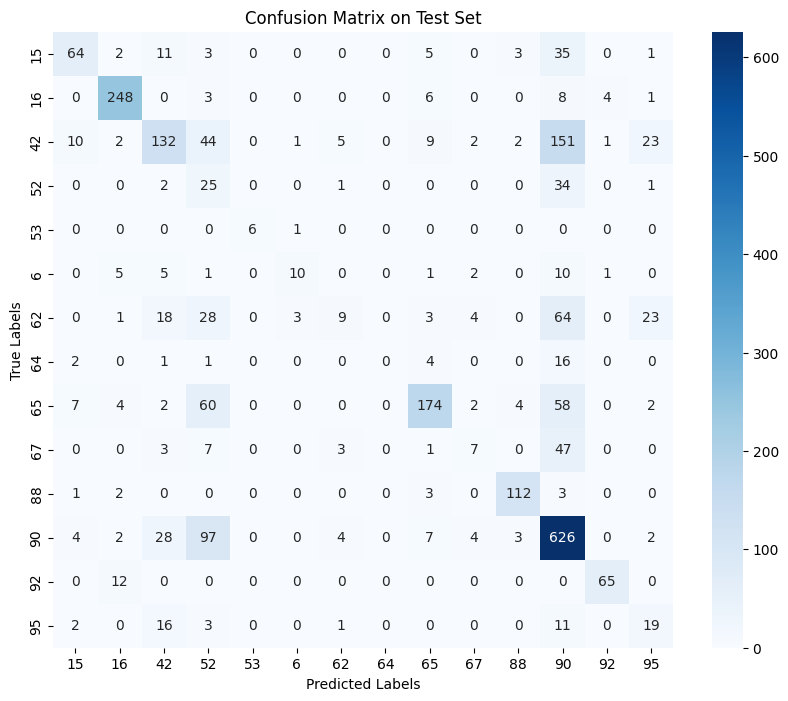

In [12]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(model, loader, device, label_names):
    model.eval()  
    all_preds = []
    all_labels = []

    with torch.no_grad(): 
        for batch_X, batch_y in loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    # Calcul des métriques
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro') 

    print(f"--- TEST METRICS ---")
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"F1-Score (Macro): {f1:.4f}")
    print("\nDetailed Report:")
    print(classification_report(all_labels, all_preds, target_names=[str(c) for c in label_names]))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix on Test Set')
    plt.show()

evaluate_model(model, test_loader, device, unique_classes)

The ResNet baseline shows highly heterogeneous performance across
classes. Classes 90, 16 and 65 which are the largest in the test set are well
recovered. Class 53 achieves perfect recall, though its test size is negligible.

The dominant failure pattern is clear: class 90 attracts many pradections,
absorbing misclassifications from nearly every other class. This is a direct
consequence of training with standard cross-entropy on a heavily imbalanced
dataset. 

The model develops a strong prior toward the majority class.
The most affected classes are 42, 62, 67 and 65. 

Classes 95, 64 and 52 are almost invisible to the model,
with correct predictions in the single digits relative to their test size.

## 5. Adapting a Foundation Model

### 5.1 Motivation

ResNet provides a solid discriminative baseline, but it is trained from
scratch on a small, domain-specific dataset. 

Can a **time series foundation model** pre-trained on large and diverse
data can transfer useful representations to this task and perform better?

We adapt **Chronos** (Ansari et al., 2024), a T5-based model pre-trained
on thousands of time series from heterogeneous domains, to the LSST
classification task. The core hypothesis is that Chronos has internalized
general temporal structure that, once fine-tuned on astronomical signals,
should outperform a purely supervised baseline — especially on minority
classes where labeled data is scarce.

In [28]:
!pip install chronos-forecasting accelerate bitsandbytes peft -U


In [29]:
import torch
import torch.nn as nn
import numpy as np
from chronos import ChronosPipeline
from peft import get_peft_model, LoraConfig
from sklearn.metrics import f1_score, classification_report
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import DataLoader
import copy

In [30]:
def get_loaders(train_loader, val_loader, bs=128):
    train_ds, val_ds = train_loader.dataset, val_loader.dataset
    t_loader = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=2, pin_memory=True)
    v_loader = DataLoader(val_ds, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)
    return t_loader, v_loader

def get_stats(x):
    with torch.no_grad():
        mu = x.mean(dim=1)
        sd = x.std(dim=1)
        mv = x.max(dim=1)[0]
        mn = x.min(dim=1)[0]
        p2p = mv - mn
        flux = x.sum(dim=1)
        return torch.cat([mu, sd, mv, mn, p2p, flux], dim=1).float()


### 5.2 Handling Class Imbalance: Focal Loss

The LSST training set is severely imbalanced. Standard cross-entropy treats all samples equally, which leads the model to over-optimize on majority classes.

**Focal Loss** (Lin et al., 2017) addresses this by down-weighting
well-classified examples via a modulating factor $(1 - p_t)^\gamma$,
effectively focusing gradient updates on hard and underrepresented samples.

We use $\gamma = 1.5$, a conservative setting that applies moderate
reweighting without destabilizing training.

In [31]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5, weight=None):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=weight, reduction="none")
    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        loss = ((1 - pt) ** self.gamma) * ce_loss
        return loss.mean()

### 5.3 Architecture: Chronos-LoRA

The model — referred to as `HybridTS` in the code — is built around the
Chronos encoder fine-tuned via LoRA (Hu et al., 2022). LoRA injects
trainable low-rank matrices into the `q` and `v` attention projections
(r=16, alpha=32), allowing domain adaptation while keeping most encoder
weights frozen. This is critical here: full fine-tuning on ~500 samples
would lead to catastrophic forgetting of the pre-trained representations.

Four learnable soft prompt tokens are prepended to the input, acting
as task-specific context vectors that condition the encoder on the
classification objective.

The architecture is augmented with a statistical branch computing 6
descriptors per photometric band (`mean`, `std`, `max`, `min`,
`peak-to-peak`, `total flux`), projected to 64 dimensions. Both branches
are concatenated before the classification head — combining the encoder's
learned temporal representations with explicit photometric descriptors.

In [32]:
class HybridTS(nn.Module):
    def __init__(self, m_name="amazon/chronos-t5-mini", n_cls=14):
        super().__init__()
        pipe = ChronosPipeline.from_pretrained(m_name, device_map="auto", dtype=torch.float16)
        self.enc = get_peft_model(pipe.model.model.encoder, LoraConfig(
            r=16, lora_alpha=32, target_modules=["q", "v"], lora_dropout=0.1
        ))
        self.dim = pipe.model.model.config.d_model
        self.proj = nn.Linear(6, self.dim)
        self.prompts = nn.Parameter(torch.randn(1, 4, self.dim) * 0.02)

        self.s_proj = nn.Sequential(
            nn.Linear(36, 64),
            nn.BatchNorm1d(64),
            nn.GELU()
        )

        self.head = nn.Sequential(
            nn.Linear((4 * self.dim) + 64, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, n_cls)
        )

    def forward(self, x):
        if x.shape[1] == 6:
            x = x.transpose(1, 2)
        b = x.size(0)
        f_stat = self.s_proj(get_stats(x).to(x.device))

        z = self.proj(x).to(torch.float16)
        p = self.prompts.expand(b, -1, -1).to(torch.float16)
        h = self.enc(inputs_embeds=torch.cat([p, z], dim=1)).last_hidden_state
        f_seq = h[:, :4, :].reshape(b, -1).to(torch.float32)

        return self.head(torch.cat([f_seq, f_stat], dim=1))

### 5.3 Training Configuration

Compared to the ResNet baseline, the training setup is adapted to the
constraints of fine-tuning a pre-trained encoder on an imbalanced dataset.

| Component | Choice | Justification |
|---|---|---|
| Loss | `CrossEntropy` ; `FocalLoss` (γ=1.5) | Focuses training on hard and minority-class samples |
| Optimizer | `AdamW` (wd=0.05) | Weight decay is essential when fine-tuning large encoders |
| LR Scheduler | `OneCycleLR` (max_lr=2e-3) | Fast convergence with aggressive warmup, suited for fine-tuning |
| Epochs | 100 | Transfer learning converges much faster than training from scratch |
| Mixed Precision | `autocast` | Required to handle float16 Chronos weights efficiently |
| Best model | Validation **F1-macro** | More reliable than training loss under class imbalance |

In [33]:
def run_train(model, t_loader, v_loader, counts, criterion, epochs=100, dev="cuda"):
    if counts is not None:
        w = 1.0 / (np.sqrt(counts) + 1e-6)
        w = torch.tensor(w / w.max() * 2.0, dtype=torch.float32).to(dev)
    else:
        w = None

    if isinstance(criterion, FocalLoss):
        crit = FocalLoss(gamma=1.5, weight=w)
    else:
        crit = nn.CrossEntropyLoss(weight=w)
    
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.05)
    sched = OneCycleLR(opt, max_lr=2e-3, steps_per_epoch=len(t_loader), epochs=epochs)
    scaler = torch.amp.GradScaler('cuda')

    best_f1 = 0.0
    for e in range(epochs):
        model.train()
        for bx, by in t_loader:
            if bx.shape[1] == 6: bx = bx.transpose(1, 2)
            bx, by = bx.to(dev), by.to(dev)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                logits = model(bx)
                loss = crit(logits, by)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            sched.step()

        model.eval()
        p, t = [], []
        with torch.no_grad(), torch.amp.autocast('cuda'):
            for bx, by in v_loader:
                if bx.shape[1] == 6: bx = bx.transpose(1, 2)
                logits = model(bx.to(dev))
                p.extend(torch.argmax(logits, dim=1).cpu().numpy())
                t.extend(by.numpy())

        score = f1_score(t, p, average='macro', zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_wts = copy.deepcopy(model.state_dict())
        if (e + 1) % 10 == 0:
            print(f"E {e+1:03d} | F1: {score:.4f} | Best: {best_f1:.4f}")

    model.load_state_dict(best_wts)
    return model

### 5.4 Training and Evaluation

Class counts are used to monitor imbalance but not to re-weight the
loss directly, and FocalLoss handles this implicitly. The model is evaluated
on the validation set after each epoch, and the best checkpoint is selected
on macro F1-score.

### Cross Entropy Loss

In [34]:
device = torch.device("cuda")

fast_train_loader, fast_val_loader = get_loaders(train_loader, val_loader)

net_1 = HybridTS().to(device)
net_1 = run_train(net_1, fast_train_loader, fast_val_loader, counts=None, criterion=nn.CrossEntropyLoss())

E 010 | F1: 0.2358 | Best: 0.2358
E 020 | F1: 0.3922 | Best: 0.4346
E 030 | F1: 0.4884 | Best: 0.5112
E 040 | F1: 0.5016 | Best: 0.5264
E 050 | F1: 0.4949 | Best: 0.5475
E 060 | F1: 0.5594 | Best: 0.5594
E 070 | F1: 0.5605 | Best: 0.5850
E 080 | F1: 0.5860 | Best: 0.6039
E 090 | F1: 0.5784 | Best: 0.6039
E 100 | F1: 0.5749 | Best: 0.6039


--- TEST METRICS ---
Accuracy: 67.19%
F1-Score (Macro): 0.5224

Detailed Report:
              precision    recall  f1-score   support

          15       0.65      0.66      0.66       124
          16       0.93      0.89      0.91       270
          42       0.52      0.37      0.43       382
          52       0.25      0.06      0.10        63
          53       0.83      0.71      0.77         7
           6       0.41      0.26      0.32        35
          62       0.37      0.32      0.34       153
          64       0.00      0.00      0.00        24
          65       0.72      0.87      0.79       313
          67       0.55      0.18      0.27        68
          88       0.94      0.94      0.94       121
          90       0.65      0.84      0.73       777
          92       0.92      0.87      0.89        77
          95       0.26      0.12      0.16        52

    accuracy                           0.67      2466
   macro avg       0.57      0.51      0.52      2466

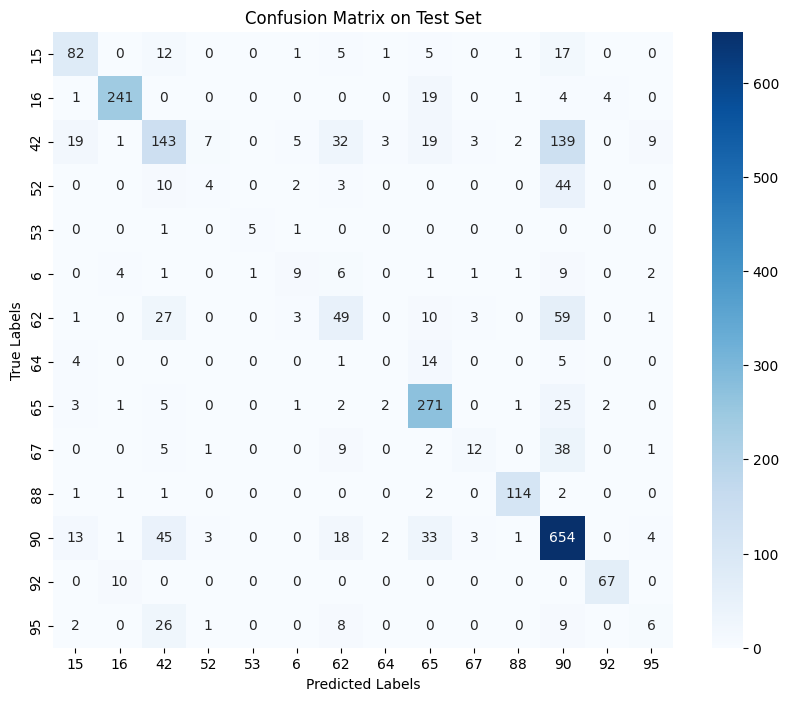

In [35]:
evaluate_model(net_1, test_loader, device, unique_classes)

Chronos with Cross-Entropy outperforms the ResNet baseline. The pre-trained encoder captures temporal structure that a model trained from scratch cannot learn on this dataset size.That said, the confusion matrix is clear: minority classes are largely ignored. The model defaults to majority classes, especially 90 and 42. Cross-Entropy gives no reason to do otherwise. It does not care about class balance.

### Cross Entropy Loss + Counts 

In [36]:
counts = np.array([25, 54, 76, 12, 1, 7, 31, 5, 63, 14, 24, 155, 15, 10])
device = torch.device("cuda")

fast_train_loader, fast_val_loader = get_loaders(train_loader, val_loader)

net_1_c = HybridTS().to(device)
net_1_c = run_train(net_1_c, fast_train_loader, fast_val_loader, counts, criterion=nn.CrossEntropyLoss())

E 010 | F1: 0.2547 | Best: 0.2547
E 020 | F1: 0.4569 | Best: 0.4914
E 030 | F1: 0.5000 | Best: 0.5158
E 040 | F1: 0.5306 | Best: 0.5679
E 050 | F1: 0.5151 | Best: 0.5861
E 060 | F1: 0.5637 | Best: 0.5861
E 070 | F1: 0.5566 | Best: 0.5861
E 080 | F1: 0.5694 | Best: 0.6085
E 090 | F1: 0.5954 | Best: 0.6085
E 100 | F1: 0.5955 | Best: 0.6085


--- TEST METRICS ---
Accuracy: 65.90%
F1-Score (Macro): 0.5408

Detailed Report:
              precision    recall  f1-score   support

          15       0.63      0.60      0.61       124
          16       0.92      0.90      0.91       270
          42       0.51      0.44      0.47       382
          52       0.10      0.11      0.11        63
          53       0.78      1.00      0.88         7
           6       0.38      0.23      0.29        35
          62       0.30      0.29      0.30       153
          64       0.10      0.08      0.09        24
          65       0.72      0.85      0.78       313
          67       0.34      0.37      0.35        68
          88       0.97      0.95      0.96       121
          90       0.71      0.76      0.74       777
          92       0.89      0.86      0.87        77
          95       0.30      0.17      0.22        52

    accuracy                           0.66      2466
   macro avg       0.55      0.54      0.54      2466

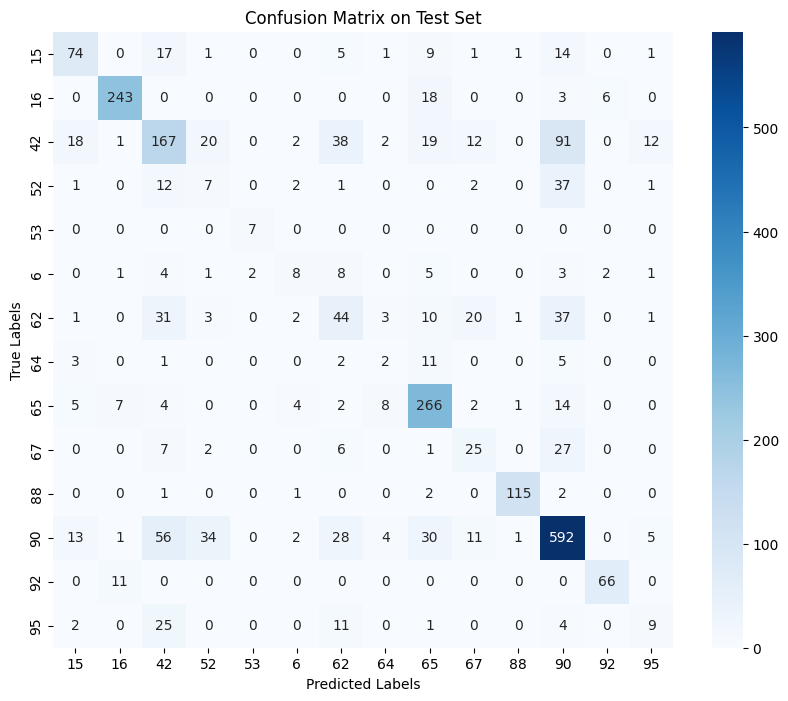

In [37]:
evaluate_model(net_1_c, test_loader, device, unique_classes)

### Focal Loss

In [43]:
device = torch.device("cuda")

fast_train_loader, fast_val_loader = get_loaders(train_loader, val_loader)

net_2 = HybridTS().to(device)
net_2 = run_train(net_2, fast_train_loader, fast_val_loader, counts = None, criterion=FocalLoss())

E 010 | F1: 0.1735 | Best: 0.2322
E 020 | F1: 0.3795 | Best: 0.4048
E 030 | F1: 0.4756 | Best: 0.4965
E 040 | F1: 0.5360 | Best: 0.5552
E 050 | F1: 0.5552 | Best: 0.5677
E 060 | F1: 0.5982 | Best: 0.5982
E 070 | F1: 0.5811 | Best: 0.5982
E 080 | F1: 0.5870 | Best: 0.5982
E 090 | F1: 0.5849 | Best: 0.6053
E 100 | F1: 0.5879 | Best: 0.6053


--- TEST METRICS ---
Accuracy: 68.17%
F1-Score (Macro): 0.5387

Detailed Report:
              precision    recall  f1-score   support

          15       0.66      0.62      0.64       124
          16       0.94      0.93      0.93       270
          42       0.52      0.43      0.47       382
          52       0.38      0.05      0.08        63
          53       0.86      0.86      0.86         7
           6       0.56      0.26      0.35        35
          62       0.33      0.29      0.31       153
          64       0.00      0.00      0.00        24
          65       0.75      0.89      0.81       313
          67       0.41      0.25      0.31        68
          88       0.96      0.91      0.93       121
          90       0.67      0.83      0.74       777
          92       0.89      0.87      0.88        77
          95       0.33      0.15      0.21        52

    accuracy                           0.68      2466
   macro avg       0.59      0.52      0.54      2466

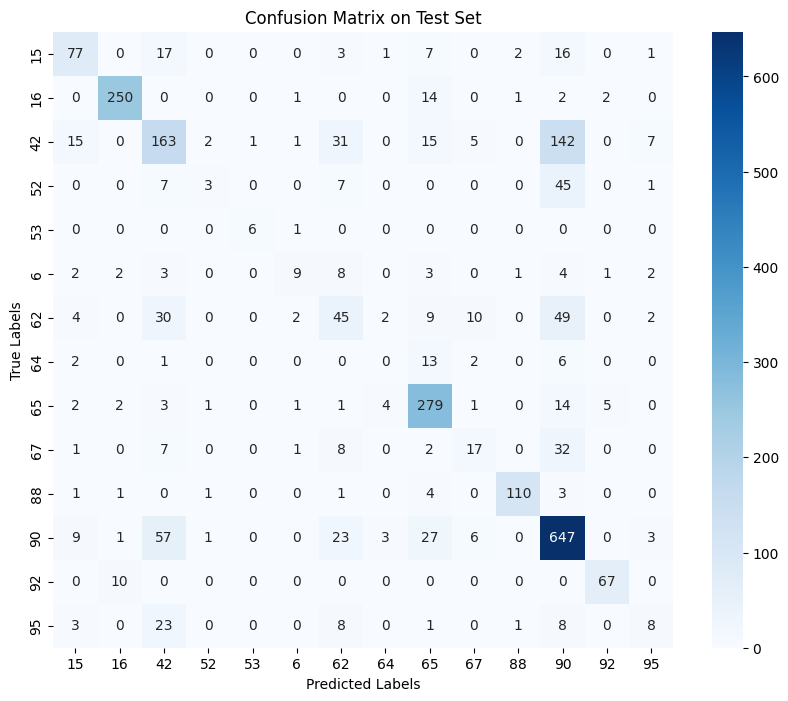

In [44]:
evaluate_model(net_2, test_loader, device, unique_classes)

### Focal Loss + Counts

In [45]:
counts = np.array([25, 54, 76, 12, 1, 7, 31, 5, 63, 14, 24, 155, 15, 10])
device = torch.device("cuda")

fast_train_loader, fast_val_loader = get_loaders(train_loader, val_loader)

net_2_c = HybridTS().to(device)
net_2_c = run_train(net_2_c, fast_train_loader, fast_val_loader, counts, criterion=FocalLoss())

E 010 | F1: 0.2737 | Best: 0.2737
E 020 | F1: 0.3682 | Best: 0.3682
E 030 | F1: 0.3917 | Best: 0.4416
E 040 | F1: 0.4859 | Best: 0.4859
E 050 | F1: 0.5140 | Best: 0.5140
E 060 | F1: 0.4869 | Best: 0.5350
E 070 | F1: 0.5156 | Best: 0.5504
E 080 | F1: 0.5385 | Best: 0.5584
E 090 | F1: 0.5459 | Best: 0.5590
E 100 | F1: 0.5482 | Best: 0.5590


--- TEST METRICS ---
Accuracy: 51.50%
F1-Score (Macro): 0.5023

Detailed Report:
              precision    recall  f1-score   support

          15       0.58      0.68      0.63       124
          16       0.88      0.88      0.88       270
          42       0.44      0.30      0.36       382
          52       0.08      0.29      0.12        63
          53       0.78      1.00      0.88         7
           6       0.27      0.26      0.26        35
          62       0.22      0.34      0.27       153
          64       0.14      0.33      0.19        24
          65       0.73      0.67      0.70       313
          67       0.19      0.41      0.26        68
          88       0.88      0.93      0.90       121
          90       0.67      0.39      0.49       777
          92       0.86      0.87      0.86        77
          95       0.17      0.40      0.24        52

    accuracy                           0.52      2466
   macro avg       0.49      0.55      0.50      2466

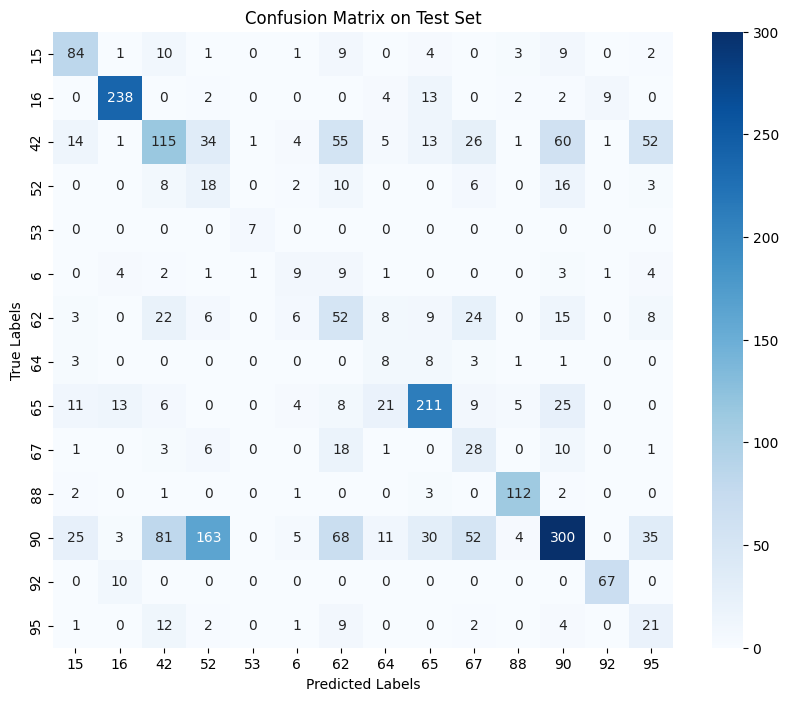

In [46]:
evaluate_model(net_2_c, test_loader, device, unique_classes)

Focal Loss fixes the main issue. Minority classes that were invisible before now get correctly predicted. The over-prediction of class 90 is reduced. Macro F1 improves.
The majority classes lose a bit of precision, this is expected and acceptable. The overall balance is better. Focal Loss is the right choice for this dataset.

Let's plot the classes having the worst f1 scores

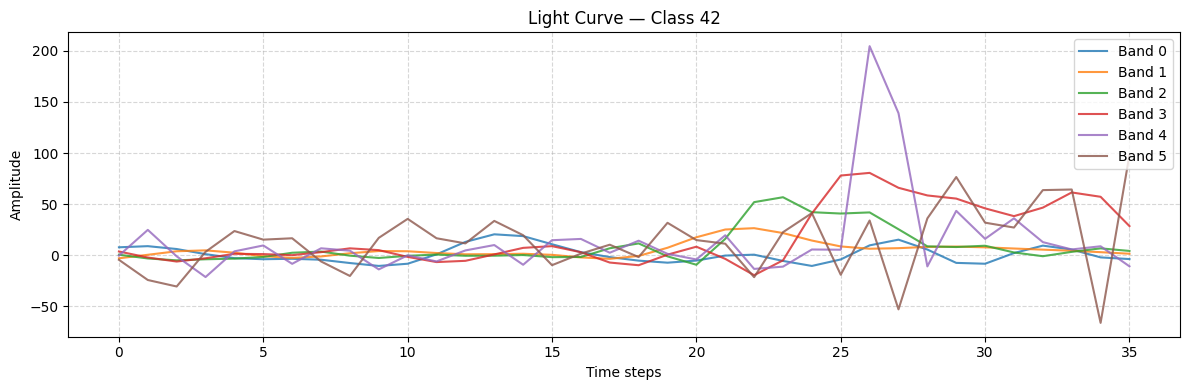

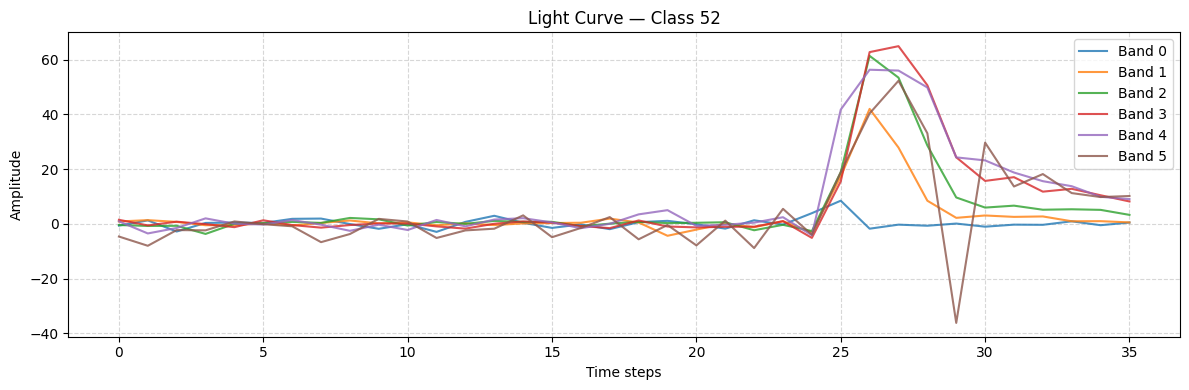

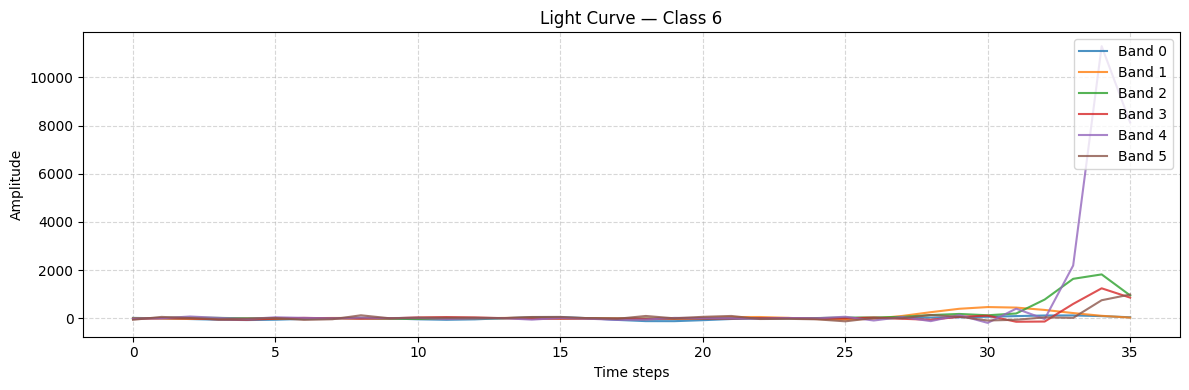

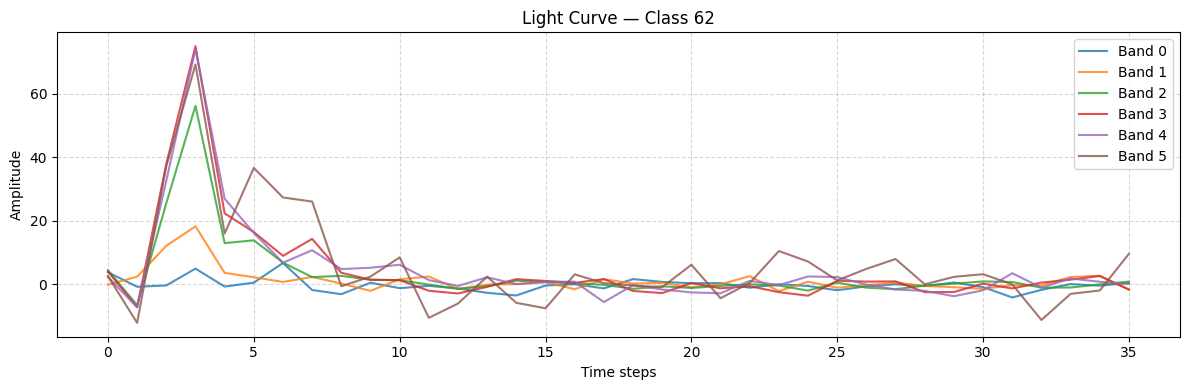

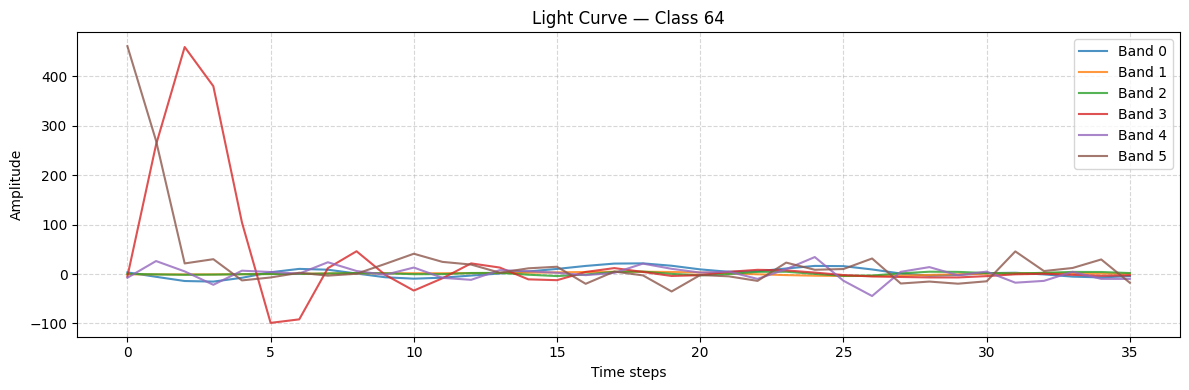

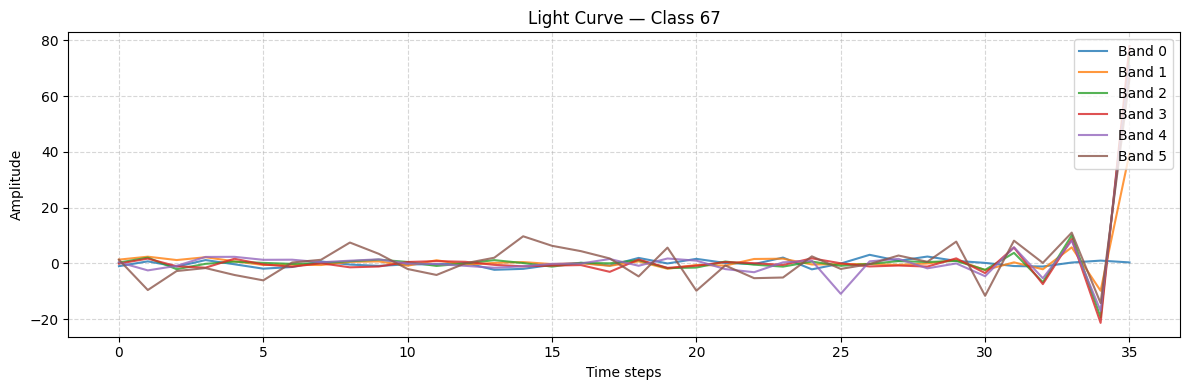

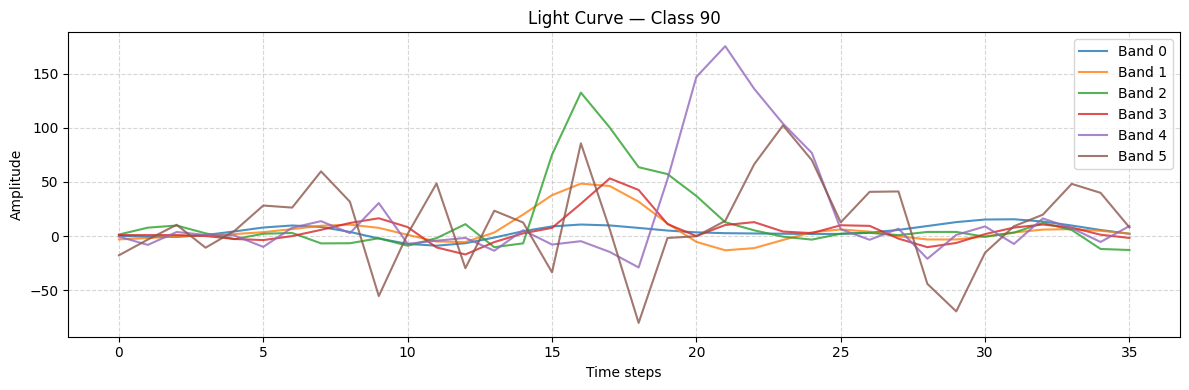

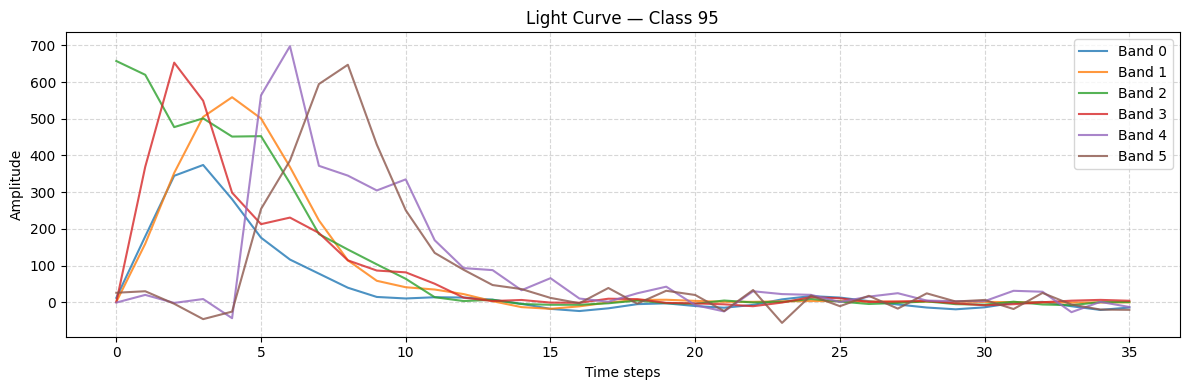

In [47]:
for cls in ['42', '52', '6', '62' , '64', '67', '90', '95']:
    idxs = np.where(y_train == cls)[0]
    sample = X_train[idxs[0]]
    
    plt.figure(figsize=(12, 4))
    for channel in range(sample.shape[1]):
        plt.plot(sample[:, channel], label=f'Band {channel}', alpha=0.8, linewidth=1.5)
    plt.title(f'Light Curve — Class {cls}')
    plt.xlabel('Time steps')
    plt.ylabel('Amplitude')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()